# 1-D TEM Inversion Notebook


In the previous notebooks (`pytem_fwd.ipynb` and `pytem_getJ.ipynb`), pyTEM's forward modeling capability was demonstrated and validated against analytical half-space solutions. That work established **accuracy**: the simulated $\mathrm{d}B/\mathrm{d}t$ responses match independent references across the full time range.


In [12]:
import sys
import time
import importlib

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, r'C:\Users\pamcl\OneDrive - Danmarks Tekniske Universitet\Dokumenter\Projects\Python\pyTEM')

# Forward functions — introduced in pytem_fwd.ipynb, imported here.
from pytem import (
    fwd_circle_central,
    fwd_circle_offset,
    fwd_square_central,
    fwd_square_offset,
    MU0,
    HAS_NUMBA,
    HAS_CUDA,
    HANKEL_FILTERS,
    FOURIER_FILTERS,
    EULER_PARAMS,
    getJ_ana,
    getJ_fd,
)

# TE-mode recursion + gradient — defined in pytem/recursion.py.
# Imported here so the inversion helpers below can use it without
# duplicating the Wait recursion derivation.
from pytem.recursion import te_reflection_coeff_grad

# Plotting utilities.
from pytem.plotter import plot_model, plot_sounding, plot_inversion


In [13]:
times = np.logspace(-5, -2, 31)
loop_side = 50.0
L = loop_side
a = np.sqrt((L**2) / np.pi)

depths0 = np.array([0.0, 5.0, 10.0, 20.0, 30.0, 45.0, 100.0])
thicknesses0 = np.diff(depths0)

z = depths0[:-1]
z_norm = (z - z.min()) / (z.max() - z.min())

base_trend = 180 - 80 * z_norm
undulation = 50 * np.sin(2 * np.pi * 1.2 * z_norm)
shallow_high = 10 * np.exp(-0.5 * ((z_norm - 0.18) / 0.10) ** 2)
mid_low = -50 * np.exp(-0.5 * ((z_norm - 0.60) / 0.12) ** 2)
deep_high = 10 * np.exp(-0.5 * ((z_norm - 0.88) / 0.08) ** 2)
rho0 = base_trend + undulation + shallow_high + mid_low + deep_high

rel_noise = 0.01
noise_at_1ms = 1e-10
obs_data = -fwd_circle_central(
    thicknesses=thicknesses0,
    resistivities=rho0,
    tx_radius=a,
    times=times,
    use_numba=False,
)

noise_floor = noise_at_1ms * (times / 1e-3) ** (-0.5)
noise_std = np.sqrt((rel_noise * obs_data) ** 2 + noise_floor ** 2)
obs_data += np.random.normal(size=obs_data.shape) * noise_std

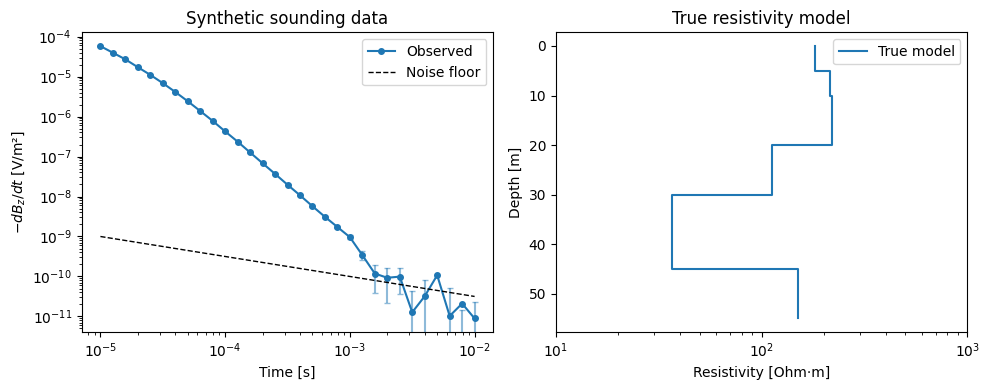

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

plot_sounding(times, obs_data, ax=axs[0],
              labels=['Observed'], styles=['o-'],
              title='Synthetic sounding data')
axs[0].errorbar(times, obs_data, yerr=noise_std,
                fmt='none', color='C0', capsize=2, alpha=0.5)
axs[0].loglog(times, noise_floor, '--', color='k', lw=1, label='Noise floor')
axs[0].legend()

plot_model(thicknesses0, rho0, ax=axs[1],
           label='True model', xlim=(10, 1000),
           title='True resistivity model')

fig.tight_layout()
plt.show()


## 1. Inversion Theory

Following Constable, Parker & Constable (1987, *Occam's inversion*, Geophysics 52, 289-300) and Binley & Slater (2020, *Resistivity and Induced Polarization*, Cambridge University Press, Ch. 6), we recover the 1-D log-resistivity model $\mathbf{m} = \ln\boldsymbol{\rho}$ by minimising a regularised objective function:

$$\Phi(\mathbf{m}) = \Phi_d(\mathbf{m}) + \alpha\,\Phi_m(\mathbf{m})$$

$$\Phi_d = \|\mathbf{W}_d\bigl(\ln\mathbf{d} - \ln F(\mathbf{m})\bigr)\|_2^2, \qquad \Phi_m = \mathbf{m}^T \mathbf{R}\,\mathbf{m}$$

where $\mathbf{W}_d = \mathrm{diag}(1/\sigma_i)$ is a diagonal data-weighting matrix, $\mathbf{R}$ is the first-order roughness (smoothness) matrix, and $\alpha$ is the regularisation parameter that controls the trade-off between data fit and model smoothness.

At each Gauss-Newton iteration the model update $\Delta\mathbf{m}$ is found by solving:

$$\left(\mathbf{J}_w^T\mathbf{J}_w + \alpha\,\mathbf{R}\right)\Delta\mathbf{m} = \mathbf{J}_w^T\mathbf{r}_w$$

where $\mathbf{J}_w = \mathbf{W}_d\,\mathbf{J}$ and $\mathbf{r}_w = \mathbf{W}_d(\ln\mathbf{d} - \ln F(\mathbf{m}_k))$.


In [15]:
# ------------------------------------------------------------------
# Inversion helpers  (mirrored from pytem/inversion.py)
# ------------------------------------------------------------------

def getR(resistivities, damp=1e-4):
    """First-order roughness (smoothness) matrix with optional damping."""
    n_params = np.asarray(resistivities).size
    D = np.zeros((n_params - 1, n_params))
    for k in range(n_params - 1):
        D[k, k] = -1.0
        D[k, k + 1] = 1.0
    R = D.T @ D + damp * np.eye(n_params)
    return R


def getRMS(obs_data, mod_data, obs_noise):
    """Root-mean-square misfit normalised by noise."""
    total_points = obs_data.size
    data_residual = (mod_data - obs_data) ** 2 / obs_noise ** 2
    return np.sqrt(np.sum(data_residual) / total_points)


def getAlpha(alpha_start, step, alpha_step=1/9):
    """Log-spaced regularisation parameter for a given cooling step."""
    log_alpha = np.log10(alpha_start) - alpha_step * step
    return 10 ** log_alpha


def getAlphas(alpha, thicknesses):
    """Depth-weighted regularisation vector."""
    thicknesses = np.asarray(thicknesses)
    tops = np.cumsum(np.concatenate(([0], thicknesses[:-1])))
    midpoints = tops + thicknesses / 2.0
    del_z = np.diff(midpoints)
    alpha_factor = np.empty(len(del_z) + 1, dtype=del_z.dtype)
    alpha_factor[0] = 1.0 / del_z[0]
    alpha_factor[1:-1] = 1.0 / del_z[:-1] + 1.0 / del_z[1:]
    alpha_factor[-1] = 1.0 / del_z[-1]
    return alpha * alpha_factor


def dbdt_to_apprho(obs_data, tx_area, times):
    """Convert dB/dt to apparent resistivity."""
    M = tx_area
    term = (2 * MU0 * M) / (5 * times * obs_data)
    app_rho = (MU0 / (4 * np.pi * times)) * (term ** (2 / 3))
    return app_rho


def _gn_solve(Jw, dw, R, alpha_vector, m):
    """Solve the weighted, regularised Gauss-Newton normal equations.

    Solves  (Jw^T Jw + diag(alpha) R) dm = Jw^T dw - diag(alpha) R m
    """
    AR  = np.diag(alpha_vector) @ R
    lhs = Jw.T @ Jw + AR
    rhs = Jw.T @ dw - AR @ m
    dm, _, _, _ = np.linalg.lstsq(lhs, rhs, rcond=1e-10)
    return dm


def _backtrack(m, delta, ln_rho_min, ln_rho_max):
    """Halve the step length until the trial model is within bounds."""
    step = 1.0
    for _ in range(10):
        trial = m + step * delta
        if np.all(trial >= ln_rho_min) and np.all(trial <= ln_rho_max):
            return trial, step
        step *= 0.5
    return np.clip(m + step * delta, ln_rho_min, ln_rho_max), step


def _alpha_search(alpha_start, alpha_steps, Jw, dw, R, m,
                  thicknesses, fwd_fn, obs_data, w,
                  ln_rho_min, ln_rho_max, alpha_step=1/9,
                  rms_current=np.inf, plot=False):
    """Log-spaced alpha search with parabola backtrack to RMS = 1.

    Returns
    -------
    alpha_hist : list of float
    rms_hist   : list of float
    delta_hist : list of ndarray  (m_trial - m)
    mod_hist   : list of ndarray  (forward response for each trial)
    """
    alpha_hist, rms_hist, delta_hist, mod_hist = [], [], [], []

    for i in range(alpha_steps):
        alpha = getAlpha(alpha_start, step=i, alpha_step=alpha_step)
        avs   = getAlphas(alpha, thicknesses)
        delta = _gn_solve(Jw, dw, R, avs, m)
        trial, step = _backtrack(m, delta, ln_rho_min, ln_rho_max)
        mod   = fwd_fn(trial)
        valid = (obs_data > 0) & (mod > 0)
        d_res = np.log(obs_data[valid]) - np.log(mod[valid])
        rms   = np.sqrt(np.mean((w[valid] * d_res) ** 2))
        print(f"    alpha = {alpha:.2f},  RMS = {rms:.2f}"
              + (f"  (step = {step:.2f})" if step < 1.0 else ""))
        alpha_hist.append(alpha)
        rms_hist.append(rms)
        delta_hist.append(trial - m)
        mod_hist.append(mod)

        if rms < 1.0:
            print("    RMS below 1 — stopping for parabola fit.")
            break

        if len(rms_hist) > 1 and rms > rms_hist[-2] and min(rms_hist[:-1]) < rms_current:
            print("    RMS increased — stopping alpha search early.")
            break

    # Polynomial backtrack to find alpha* where RMS = 1
    x_data = np.log10(np.array(alpha_hist))
    y_data = np.array(rms_hist)
    deg    = min(2, len(x_data) - 1)
    parabola_alpha = None
    coeffs         = None

    if deg >= 1 and np.min(y_data) < 1.0:
        coeffs      = np.polyfit(x_data, y_data, deg)
        root_c      = coeffs.copy()
        root_c[-1] -= 1.0
        roots       = np.roots(root_c)
        x_lo, x_hi  = x_data.min() - 1.0, x_data.max() + 1.0
        real_roots  = roots[np.abs(roots.imag) < 1e-10].real
        valid_roots = real_roots[(real_roots >= x_lo) & (real_roots <= x_hi)]

        if valid_roots.size > 0:
            parabola_x     = float(valid_roots.max())
            parabola_alpha = 10.0 ** parabola_x
            avs_par        = getAlphas(parabola_alpha, thicknesses)
            delta_par      = _gn_solve(Jw, dw, R, avs_par, m)
            trial_par, step_par = _backtrack(m, delta_par, ln_rho_min, ln_rho_max)
            mod_par   = fwd_fn(trial_par)
            valid_par = (obs_data > 0) & (mod_par > 0)
            d_par     = np.log(obs_data[valid_par]) - np.log(mod_par[valid_par])
            rms_par   = np.sqrt(np.mean((w[valid_par] * d_par) ** 2))
            print(f"    Fitted Alpha = {parabola_alpha:.3f}"
                  f", actual RMS = {rms_par:.3f}"
                  + (f"  (step = {step_par:.2f})" if step_par < 1.0 else ""))
            alpha_hist.append(parabola_alpha)
            rms_hist.append(rms_par)
            delta_hist.append(trial_par - m)
            mod_hist.append(mod_par)

    if plot and coeffs is not None:
        fig_a, ax_a = plt.subplots(figsize=(5, 3.5))
        x_fit = np.linspace(x_data.min() - 0.5, x_data.max() + 0.5, 300)
        y_fit = np.polyval(coeffs, x_fit)
        ax_a.plot(x_fit, y_fit, '-', color='C0', lw=1.5, label=f'Degree-{deg} fit')
        ax_a.plot(x_data, y_data, 'o', color='C1', zorder=5, label='Tested alphas')
        ax_a.axhline(1.0, color='k', ls='--', lw=1, label='RMS = 1 target')
        if parabola_alpha is not None:
            ax_a.axvline(np.log10(parabola_alpha), color='C2', ls='--', lw=1,
                         label=f'$\\alpha^* = {parabola_alpha:.3g}$')
            ax_a.plot(np.log10(parabola_alpha), 1.0, '*', color='C2',
                      markersize=12, zorder=6)
        ax_a.set_xlabel('$\\log_{{10}}(\\alpha)$')
        ax_a.set_ylabel('RMS')
        ax_a.grid(True, alpha=0.3)
        fig_a.tight_layout()
        plt.show()

    return alpha_hist, rms_hist, delta_hist, mod_hist


## 2. Inversion Setup

The inversion uses a 1-D log-spaced layered mesh with a homogeneous starting model.


In [16]:
depths = np.array([1., 2.088, 3.272, 4.56, 5.962, 7.487, 9.147,
                   10.953, 12.918, 15.056, 17.382, 19.913, 22.667, 
                   25.664, 28.925, 32.473, 36.334, 40.535, 45.106, 
                   50.08 , 55.492, 61.381, 67.789, 74.762, 82.349, 
                   90.604, 99.587, 109.361, 120.001])

thicknesses = np.diff(depths).tolist()
log_resistivities = np.ones_like(thicknesses) * 4.5

In [17]:
# The central-loop circle geometry is the fastest
# option (no side integration required) and the 101-pt DLF is accurate to
# < 0.1 % relative to the 201-pt reference.  We bind these choices here so
# the rest of the notebook uses a single, easy-to-swap definition.


FWD_HANKEL   = 'key_101'            # Hankel filter
FWD_FOURIER  = 'key_81'            # Fourier filter
FWD_NUMBA    = HAS_NUMBA            # use Numba JIT if available
FWD_CUDA     = HAS_CUDA             # use CUDA if available

## 3. Jacobian and Regularisation

Before running the inversion, the finite-difference Jacobian is inspected to confirm the expected depth and gate sensitivity structure. The smoothness matrix $\mathbf{R}$ is also visualised.


### Smoothness and Regularisation

The roughness matrix $\mathbf{R} = \mathbf{D}^T\mathbf{D} + \delta\mathbf{I}$ is built from the first-difference operator $\mathbf{D}$, which penalises sharp jumps in $\ln\rho$ between adjacent layers. A small damping term $\delta$ ensures $\mathbf{R}$ is invertible.

`getAlphas()` applies a depth-weighting so that the penalty per unit log-resistivity change is proportional to the inverse of the layer midpoint spacing. This prevents thin layers near the surface from being over-regularised relative to the thick deep layers.

The regularisation parameter $\alpha$ is cooled over iterations using a log-linear schedule (`getAlpha()`): large early to stabilise convergence, then reduced to allow finer structure as the data misfit approaches 1.

## 4. Backend Performance: Jacobian Build Time

The dominant cost per Gauss-Newton iteration is building the finite-difference Jacobian: `getJ` makes $N + 1 = 29$ consecutive forward calls (one baseline plus one per layer). Timing `getJ` end-to-end with each backend therefore gives the most realistic measure of per-iteration speed during inversion.

The key difference from the isolated single-call benchmark in Section 1.2 is that here the GPU **stays resident across all 29 calls**. The fixed PCIe host-to-device transfer overhead is paid once and amortised over the full Jacobian build, which is why CUDA is expected to outperform Numba at this problem size even though a single isolated CUDA call can appear slower.


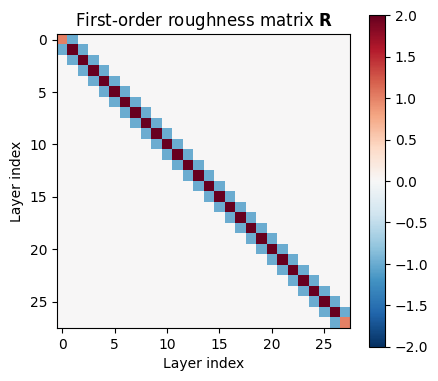

R shape: (28, 28),  diagonal range: 1.000 – 2.000


In [18]:
# ============================================================================
# Roughness matrix visualisation
# ============================================================================
R_vis = getR(np.array(thicknesses))

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(R_vis, cmap='RdBu_r', vmin=-R_vis.max(), vmax=R_vis.max())
plt.colorbar(im, ax=ax)
ax.set_title('First-order roughness matrix $\\mathbf{R}$')
ax.set_xlabel('Layer index')
ax.set_ylabel('Layer index')
fig.tight_layout()
plt.show()

print(f"R shape: {R_vis.shape},  diagonal range: {R_vis.diagonal().min():.3f} – {R_vis.diagonal().max():.3f}")

## 5. Regularised Gauss-Newton Inversion

Following Constable, Parker & Constable (1987, *Geophysics*, 52, 289–300), the objective function to minimise at each iteration is:

$$\Phi(\mathbf{m} + \Delta\mathbf{m}) = \|\mathbf{J}_w\,\Delta\mathbf{m} - \mathbf{d}_w\|_2^2 + (\mathbf{m} + \Delta\mathbf{m})^T \mathbf{A}\mathbf{R}\,(\mathbf{m} + \Delta\mathbf{m})$$

where $\mathbf{A} = \mathrm{diag}(\boldsymbol{\alpha})$ is the depth-weighted regularisation diagonal. Differentiating with respect to $\Delta\mathbf{m}$ and setting to zero gives the corrected normal equations:

$$\left(\mathbf{J}_w^T\mathbf{J}_w + \mathbf{A}\mathbf{R}\right)\Delta\mathbf{m} = \mathbf{J}_w^T\mathbf{d}_w - \mathbf{A}\mathbf{R}\,\mathbf{m}$$

The right-hand side correction $-\mathbf{A}\mathbf{R}\,\mathbf{m}$ is essential. It arises because the regularisation term penalises the **total model** $\mathbf{m} + \Delta\mathbf{m}$, not just the update $\Delta\mathbf{m}$. Without it, the normal equations only damp the step size, so the model is free to accumulate roughness across iterations and overshoot. With it, each solve exerts a restoring force proportional to how rough the current model already is, keeping $\mathbf{m}$ smooth throughout the iteration sequence.

Within each iteration a short line search over $\alpha$ is run: up to `alpha_steps` values are tried on a log-decreasing schedule (`getAlpha`). The search stops early when RMS starts rising, and the best $\alpha$ is carried forward to warm-start the next iteration. A step-halving backtrack (`_backtrack`) keeps the trial model within the user-specified resistivity bounds.


In [22]:
def invert(obs_data, thicknesses, log_resistivities, tx_radius, times,
           alpha_start=None, alpha_steps=5, alpha_step=1/9, maxit=20, eps=1e-4,
           noise_std=0.02, use_numba=True, use_cuda=True,
           calc_sens=False, store_J=False,
           transform='euler', hankel_filter='key_101', fourier_filter='key_81',
           euler_order=11, rho_min=1e-1, rho_max=1e5, max_noise_frac=0.00,
           plot_alpha=False, analytical_j=True,
           system_filter=None,
           waveform_times=None, waveform_currents=None, n_step=200,
           waveform_n_quad=5,
           geometry='circle_central', n_quad=5,
           rx_offset=0.0, rx_y=0.0, circle_warmstart=False):
    """Regularised Gauss-Newton inversion for 1-D layered-earth TEM.

    Minimises  phi(m) = ||W (ln d_obs - ln d_pred(m))||^2 + alpha * m^T R m
    using iterative Gauss-Newton updates with a log-spaced alpha search and
    parabola backtrack to target RMS = 1.

    All optimisation is performed in log-resistivity space, so the forward
    function is always evaluated with ``resistivities = exp(m)``.

    System filter
    -------------
    Pass ``system_filter`` (a callable H(omega) -> complex array) to apply a
    frequency-domain instrument response inside the forward model and the
    analytical Jacobian.  When ``analytical_j=False``, the filter is applied
    inside ``fwd_circle_central`` automatically; when ``analytical_j=True``,
    it is passed to ``getJ_ana``.

    Waveform convolution
    --------------------
    When ``waveform_times`` and ``waveform_currents`` are supplied, the step-off
    response is computed on a dense log-spaced time grid (``n_step`` points)
    and convolved with the piecewise-linear waveform using
    ``waveform.convolve_waveform``.  In this mode the Jacobian is always
    computed by finite differences (``analytical_j`` is ignored), because the
    linear convolution operator is automatically captured in the FD differences.

    Parameters
    ----------
    obs_data            : (n_t,) observed dBz/dt [T/s], positive values
    thicknesses         : (N,)   layer thicknesses [m]
    log_resistivities   : (N,)   initial ln(rho) [ln(Ohm.m)]
    tx_radius           : float  equivalent transmitter radius [m]
    times               : (n_t,) gate centre times [s]
    alpha_start         : float or None  starting regularisation strength
                          (auto-estimated from JTd if None)
    alpha_steps         : int    number of alpha values per outer iteration
    alpha_step          : float  log10 step size between consecutive alpha values
                          (default 1/9 ~ 10 steps per decade)
    maxit               : int    maximum Gauss-Newton iterations
    eps                 : float  finite-difference step for FD Jacobian
    noise_std           : float or (n_t,)  fractional noise standard deviation
    use_numba           : bool   enable Numba JIT backend
    use_cuda            : bool   enable CuPy GPU backend
    calc_sens           : bool   compute parameter sensitivity at convergence
    store_J             : bool   store Jacobian at each iteration
    transform           : 'dlf' or 'euler'
    hankel_filter       : str    (default 'key_101')
    fourier_filter      : str    (default 'key_81')
    euler_order         : int    (default 11)
    rho_min             : float  lower resistivity bound [Ohm.m] (default 0.1)
    rho_max             : float  upper resistivity bound [Ohm.m] (default 1e5)
    max_noise_frac      : float  noise floor as a fraction of peak data
    plot_alpha          : bool   show alpha-RMS plot at each iteration
    analytical_j        : bool   use analytical Jacobian (ignored when waveform)
    system_filter       : callable or None  H(omega) -> complex
    waveform_times      : array-like or None  waveform break points [s]
    waveform_currents   : array-like or None  current at break points [A]
    n_step              : int    unused (kept for backwards compatibility)
    waveform_n_quad     : int    GL quadrature order for waveform convolution

    Returns
    -------
    result : dict with keys
        'log_resistivities' : (N,)         final ln(rho)
        'resistivities'     : (N,)         final rho [Ohm.m]
        'thicknesses'       : (N,)         layer thicknesses [m]
        'model_history'     : list of (N,) all models (initial + each iteration)
        'rms_history'       : list of float  RMS after each iteration
        'J_history'         : list of (n_t, N) or None
        'sensitivity'       : (N,) or None   column-norm of final J
        'times'             : (n_t,) gate times [s]
        'obs_data'          : (n_t,) observed data
        'n_iter'            : int   number of completed iterations
    """
    # ---- Parse inputs ----
    obs_data    = np.asarray(obs_data,          dtype=float)
    thicknesses = np.asarray(thicknesses,       dtype=float)
    m           = np.asarray(log_resistivities, dtype=float).copy()
    times       = np.asarray(times,             dtype=float)

    # ---- Circle warm-start ----
    if circle_warmstart and geometry.startswith('square'):
        r_circ    = float(tx_radius) / np.sqrt(np.pi)
        circ_geom = 'circle_central' if geometry == 'square_central' else 'circle_offset'
        print(f'[circle_warmstart] Running circle pre-inversion '
              f'(geometry={circ_geom}, r={r_circ:.3f} m)...')
        ws = invert(
            obs_data=obs_data, thicknesses=thicknesses,
            log_resistivities=m, tx_radius=r_circ, times=times,
            alpha_start=alpha_start, alpha_steps=alpha_steps, alpha_step=alpha_step,
            maxit=maxit,
            eps=eps, noise_std=noise_std, use_numba=use_numba, use_cuda=use_cuda,
            calc_sens=False, store_J=False,
            transform=transform, hankel_filter=hankel_filter,
            fourier_filter=fourier_filter, euler_order=euler_order,
            rho_min=rho_min, rho_max=rho_max, max_noise_frac=max_noise_frac,
            plot_alpha=plot_alpha, analytical_j=analytical_j,
            system_filter=system_filter,
            waveform_times=waveform_times, waveform_currents=waveform_currents,
            waveform_n_quad=waveform_n_quad,
            n_step=n_step, geometry=circ_geom, n_quad=1,
            rx_offset=rx_offset, rx_y=rx_y, circle_warmstart=False,
        )
        print(f'[circle_warmstart] Circle converged (RMS={ws["rms_history"][-1]:.3f}). '
              f'Running up to {maxit} square refinement steps...')
        return invert(
            obs_data=obs_data, thicknesses=thicknesses,
            log_resistivities=ws['log_resistivities'], tx_radius=tx_radius,
            times=times,
            alpha_start=None, alpha_steps=alpha_steps, alpha_step=alpha_step,
            maxit=maxit, eps=eps,
            noise_std=noise_std, use_numba=use_numba, use_cuda=use_cuda,
            calc_sens=calc_sens, store_J=store_J,
            transform=transform, hankel_filter=hankel_filter,
            fourier_filter=fourier_filter, euler_order=euler_order,
            rho_min=rho_min, rho_max=rho_max, max_noise_frac=max_noise_frac,
            plot_alpha=plot_alpha, analytical_j=analytical_j,
            system_filter=system_filter,
            waveform_times=waveform_times, waveform_currents=waveform_currents,
            waveform_n_quad=waveform_n_quad,
            n_step=n_step, geometry=geometry, n_quad=n_quad,
            rx_offset=rx_offset, rx_y=rx_y, circle_warmstart=False,
        )

    ln_rho_min = np.log(float(rho_min))
    ln_rho_max = np.log(float(rho_max))

    # ---- Noise weighting ----
    if np.isscalar(noise_std):
        noise_abs = noise_std * np.abs(obs_data)
    else:
        noise_abs = np.asarray(noise_std, dtype=float)
    # Floor: noise cannot be smaller than max_noise_frac * peak |obs|
    noise_abs = np.maximum(noise_abs, max_noise_frac * np.abs(obs_data).max())
    # Log-space noise: sigma_log_i = sigma_i / |d_i|
    noise_log = noise_abs / np.abs(obs_data)
    w         = 1.0 / noise_log   # weight per datum in log space

    # ---- Waveform convolution setup ----
    _use_waveform = (waveform_times is not None and waveform_currents is not None)
    if _use_waveform:
        from pytem.waveform import setup_waveform as _setup_waveform
        _wf_t  = np.asarray(waveform_times,    dtype=float)
        _wf_I  = np.asarray(waveform_currents, dtype=float)
        _wf_comp_times, _wf_apply = _setup_waveform(
            times, _wf_t, _wf_I, n_quad=waveform_n_quad
        )

    _fwd_kw = dict(
        use_numba=use_numba,
        use_cuda=use_cuda,
        system_filter=system_filter,
        transform=transform,
        hankel_filter=hankel_filter,
        fourier_filter=fourier_filter,
        euler_order=euler_order,
    )

    # ---- Geometry dispatch helper ----
    def _call_fwd(thick, res, t):
        if geometry == 'circle_central':
            return -fwd_circle_central(thick, res, float(tx_radius), t, **_fwd_kw)
        elif geometry == 'circle_offset':
            return -fwd_circle_offset(thick, res, float(tx_radius),
                                      float(rx_offset), t, **_fwd_kw)
        elif geometry == 'square_central':
            return -fwd_square_central(thick, res, float(tx_radius), t,
                                       n_quad=n_quad, **_fwd_kw)
        else:  # square_offset
            return -fwd_square_offset(thick, res, float(tx_radius),
                                      float(rx_offset), float(rx_y), t,
                                      n_quad=n_quad, **_fwd_kw)

    # ---- Forward model closure ----
    def _forward_response(log_rho):
        res = np.exp(log_rho)
        if _use_waveform:
            step_resp = _call_fwd(thicknesses, res, _wf_comp_times)
            return _wf_apply(step_resp)
        return _call_fwd(thicknesses, res, times)

    # ---- Jacobian closure ----
    def _build_jacobian(log_rho):
        if analytical_j and not _use_waveform:
            _tx_geom_j = (float(tx_radius) / np.sqrt(np.pi)
                          if geometry.startswith('square') else float(tx_radius))
            return getJ_ana(
                thicknesses=thicknesses,
                log_resistivities=log_rho,
                tx_geom=_tx_geom_j,
                times=times,
                geometry=geometry,
                rx_offset=float(rx_offset),
                rx_y=float(rx_y),
                n_quad=n_quad,
                use_numba=use_numba,
                use_cuda=False,
                system_filter=system_filter,
                transform=transform,
                hankel_filter=hankel_filter,
                fourier_filter=fourier_filter,
                euler_order=euler_order,
            )

        if analytical_j and _use_waveform:
            res       = np.exp(log_rho)
            step_resp = _call_fwd(thicknesses, res, _wf_comp_times)
            _tx_geom_j = (float(tx_radius) / np.sqrt(np.pi)
                          if geometry.startswith('square') else float(tx_radius))
            J_anal = getJ_ana(
                thicknesses=thicknesses,
                log_resistivities=log_rho,
                tx_geom=_tx_geom_j,
                times=_wf_comp_times,
                geometry=geometry,
                rx_offset=float(rx_offset),
                rx_y=float(rx_y),
                n_quad=n_quad,
                use_numba=use_numba,
                use_cuda=False,
                system_filter=system_filter,
                transform=transform,
                hankel_filter=hankel_filter,
                fourier_filter=fourier_filter,
                euler_order=euler_order,
            )  # (n_unique, N)
            G  = _wf_apply(step_resp)               # (n_gates,)
            dF = J_anal * step_resp[:, None]         # (n_unique, N)
            dG = _wf_apply(dF)                       # (n_gates, N)
            J_conv = np.zeros((len(times), log_rho.size))
            valid_g = G > 0
            J_conv[valid_g, :] = dG[valid_g, :] / G[valid_g, None]
            return J_conv

        # Finite-difference Jacobian
        f0 = _forward_response(log_rho)
        J  = np.zeros((f0.size, log_rho.size))
        for i in range(log_rho.size):
            pert    = log_rho.copy()
            h       = eps * max(1.0, abs(log_rho[i]))
            pert[i] += h
            fi      = _forward_response(pert)
            valid   = (f0 > 0) & (fi > 0)
            J[valid, i] = (np.log(fi[valid]) - np.log(f0[valid])) / h
        return J

    # ---- Initial alpha heuristic ----
    print("Building initial Jacobian...")
    t0 = time.perf_counter()
    J0 = _build_jacobian(m)
    d0 = _forward_response(m)

    valid0  = (obs_data > 0) & (d0 > 0)
    res0    = np.zeros(len(obs_data))
    res0[valid0] = np.log(obs_data[valid0]) - np.log(d0[valid0])
    Jw0     = J0 * w[:, None]
    dw0     = res0 * w

    if alpha_start is None:
        alpha_start = float(np.linalg.norm(Jw0.T @ dw0, np.inf) + 1e-30)
    print(f"Alpha Start = {alpha_start:.3g}")

    # ---- Gauss-Newton loop ----
    rms_history   = []
    model_history = [m.copy()]
    J_history     = [J0.copy()] if store_J else []
    J_cur         = J0

    t_loop = time.perf_counter()
    d_pred = d0

    for it in range(maxit):
        valid  = (obs_data > 0) & (d_pred > 0)

        if not np.any(valid):
            print("WARNING: No valid data — stopping.")
            break

        res_log        = np.zeros(len(obs_data))
        res_log[valid] = np.log(obs_data[valid]) - np.log(d_pred[valid])
        rms = np.sqrt(np.mean((w[valid] * res_log[valid]) ** 2))
        rms_history.append(rms)

        print(f"Iteration {it + 1:>3d}:  RMS = {rms:.2f}")

        if rms <= 1.0:
            print("  RMS <= 1 — converged.")
            break

        if it > 0:
            J_cur = _build_jacobian(m)
            if store_J:
                J_history.append(J_cur.copy())

        R  = getR(m)
        Jw = J_cur * w[:, None]
        dw = res_log * w

        alpha_h, rms_h, delta_h, mod_h = _alpha_search(
            alpha_start, alpha_steps,
            Jw, dw, R, m,
            thicknesses, _forward_response, obs_data, w,
            ln_rho_min, ln_rho_max,
            alpha_step=alpha_step,
            rms_current=rms,
            plot=plot_alpha,
        )

        # Select best model update.
        # When any search RMS dipped below 1 (overshoot), _alpha_search appended
        # the parabola-adjusted model as the last entry.  Always prefer that entry
        # so the update lands as close to RMS = 1 as possible — even if the
        # parabola RMS ended up slightly above 1 (which the "below" filter would
        # otherwise reject).
        rms_arr   = np.array(rms_h)
        overshoot = bool(np.any(rms_arr < 1.0))
        if overshoot:
            best_idx          = len(rms_h) - 1
            raw_overshoot_rms = float(rms_arr[rms_arr < 1.0].min())
            #print(f"  Overshoot (RMS = {raw_overshoot_rms:.3f})")
        else:
            below = rms_arr[rms_arr <= 1.0]
            if below.size > 0:
                best_idx = int(np.where(rms_arr == below.max())[0][-1])
            else:
                best_idx = int(np.argmin(rms_arr))

        if rms_h[best_idx] >= rms:
            print("  No improvement found — stopping.")
            break

        alpha_start = alpha_h[best_idx] * (10.0 ** alpha_step)

        m = np.clip(m + delta_h[best_idx], ln_rho_min, ln_rho_max)
        d_pred = mod_h[best_idx]
        model_history.append(m.copy())

        # Parabola is terminal: whatever RMS it gives, that is the final answer.
        if overshoot:
            rms_history.append(rms_h[best_idx])
            break

    # ---- Optional sensitivity ----
    sensitivity = None
    if calc_sens:
        Jf          = _build_jacobian(m)
        sensitivity = np.sqrt(np.sum(Jf ** 2, axis=0))

    print(f"\nTotal time: {time.perf_counter() - t_loop:.1f} s,  "
          f"Final RMS = {rms_history[-1]:.3f}")

    return {
        'log_resistivities': m,
        'resistivities':     np.exp(m),
        'thicknesses':       thicknesses,
        'model_history':     model_history,
        'rms_history':       rms_history,
        'J_history':         J_history if store_J else None,
        'sensitivity':       sensitivity,
        'times':             times,
        'obs_data':          obs_data,
        'n_iter':            len(rms_history),
    }


### Run Inversion

Start from a homogeneous half-space and iterate until the RMS stabilises.

Building initial Jacobian...
Alpha Start = 1.39e+03
Iteration   1:  RMS = 16.78
    alpha = 1386.32,  RMS = 16.07
    alpha = 1073.38,  RMS = 16.98
    RMS increased — stopping alpha search early.
Iteration   2:  RMS = 16.07
    alpha = 1790.50,  RMS = 2.41
    alpha = 1386.32,  RMS = 2.19
    alpha = 1073.38,  RMS = 2.03
    alpha = 831.08,  RMS = 1.95
    alpha = 643.47,  RMS = 1.93
    alpha = 498.22,  RMS = 1.95
    RMS increased — stopping alpha search early.
Iteration   3:  RMS = 1.93
    alpha = 831.08,  RMS = 1.57
    alpha = 643.47,  RMS = 1.35
    alpha = 498.22,  RMS = 1.18
    alpha = 385.75,  RMS = 1.04
    alpha = 298.67,  RMS = 0.94
    RMS below 1 — stopping for parabola fit.
    Fitted Alpha = 350.477, actual RMS = 1.002


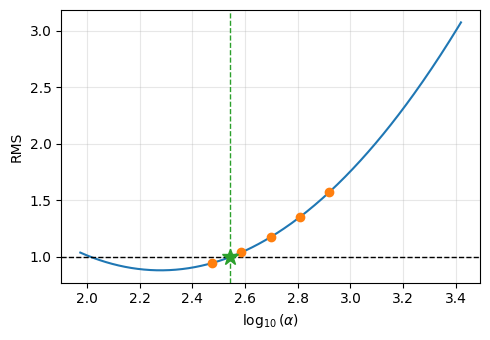


Total time: 1.4 s,  Final RMS = 1.002


In [23]:
log_resistivities = np.ones_like(thicknesses) * np.log(100.0)

result = invert(
    obs_data=obs_data,
    thicknesses=thicknesses,
    log_resistivities=log_resistivities,
    tx_radius=a,
    times=times,
    alpha_steps=10,
    maxit=10,
    eps=1e-4,
    noise_std=noise_std,
    use_cuda=True,
    calc_sens=False,
    transform='euler',
    hankel_filter='key_101',
    fourier_filter='key_81',
    max_noise_frac=0.00,
    plot_alpha=True,
    analytical_j=False,
)

# Unpack result dict
best_rho      = result['resistivities']
iter_rms_list = result['rms_history']
rho_hist      = [np.exp(m) for m in result['model_history']]

# Compute modelled response at final model for plotting
mod_data = -fwd_circle_central(
    thicknesses=thicknesses,
    resistivities=best_rho,
    tx_radius=a,
    times=times,
)


## 6. Results

Summary plots: data fit, RMS convergence history, and recovered resistivity model vs true model.


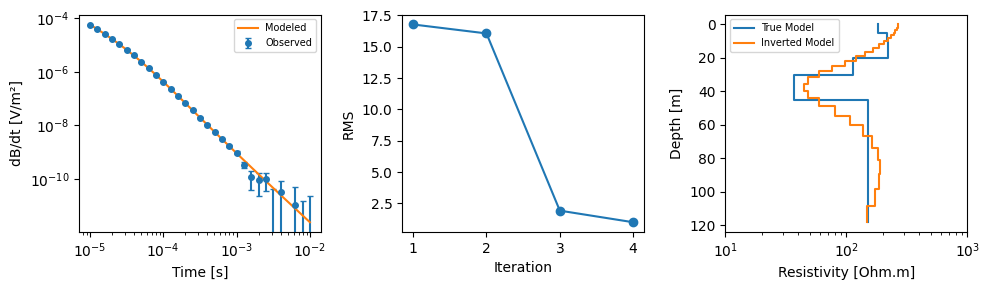

In [24]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3))

axs[0].errorbar(times, obs_data, yerr=noise_std, fmt='o', markersize=4, capsize=2, label='Observed')
axs[0].loglog(times, mod_data, '-', label='Modeled', markersize=4)
axs[0].set_xlabel('Time [s]')
axs[0].set_ylabel('dB/dt [V/m²]')
axs[0].legend(fontsize=7)

axs[1].plot(range(1, len(iter_rms_list) + 1), iter_rms_list, 'o-')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel('RMS')

depths0 = np.cumsum(np.concatenate(([0], thicknesses0[:-1])))
axs[2].step(np.r_[rho0, rho0[-1]], np.r_[depths0, depths[-1]+10], where='pre', label='True Model')
depths = np.cumsum(np.concatenate(([0], thicknesses[:-1])))
axs[2].step(np.r_[best_rho, best_rho[-1]], np.r_[depths, depths[-1]+10], where='pre', label='Inverted Model')

axs[2].invert_yaxis()
axs[2].set_xlabel('Resistivity [Ohm.m]')
axs[2].set_ylabel('Depth [m]')
axs[2].set_xscale('log')
axs[2].legend(fontsize=7)
axs[2].set_xlim(10, 1000)

fig.tight_layout()